In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:


from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:


print("Number of Samples:", data.data.shape[0])
print("Number of Features:", data.data.shape[1])

print("\nFeature Names:")
print(data.feature_names)

print("\nTarget Names:")
print(data.target_names)

Number of Samples: 569
Number of Features: 30

Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target Names:
['malignant' 'benign']


In [4]:


df = pd.DataFrame(data.data, columns=data.feature_names)

df['target'] = data.target


df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:


print("Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
0

Duplicate Rows:
0


In [6]:


X = df.drop('target', axis=1)
y = df['target']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (569, 30)
Target (y) shape: (569,)


In [7]:


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [8]:


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [9]:


from sklearn.linear_model import LogisticRegression


lr_model = LogisticRegression(max_iter=1000, random_state=42)


lr_model.fit(X_train_scaled, y_train)


y_pred_lr = lr_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [10]:


from sklearn.ensemble import RandomForestClassifier


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [11]:


from sklearn.svm import SVC



svm_model = SVC(kernel='rbf', probability=True, random_state=42)



svm_model.fit(X_train_scaled, y_train)


y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM model trained successfully!")

SVM model trained successfully!


In [12]:


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)



rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)



svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)



results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [lr_accuracy, rf_accuracy, svm_accuracy],
    'Precision': [lr_precision, rf_precision, svm_precision],
    'Recall': [lr_recall, rf_recall, svm_recall],
    'F1-Score': [lr_f1, rf_f1, svm_f1]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Random Forest,0.956140,0.958904,0.972222,0.965517
2,SVM,0.982456,0.986111,0.986111,0.986111


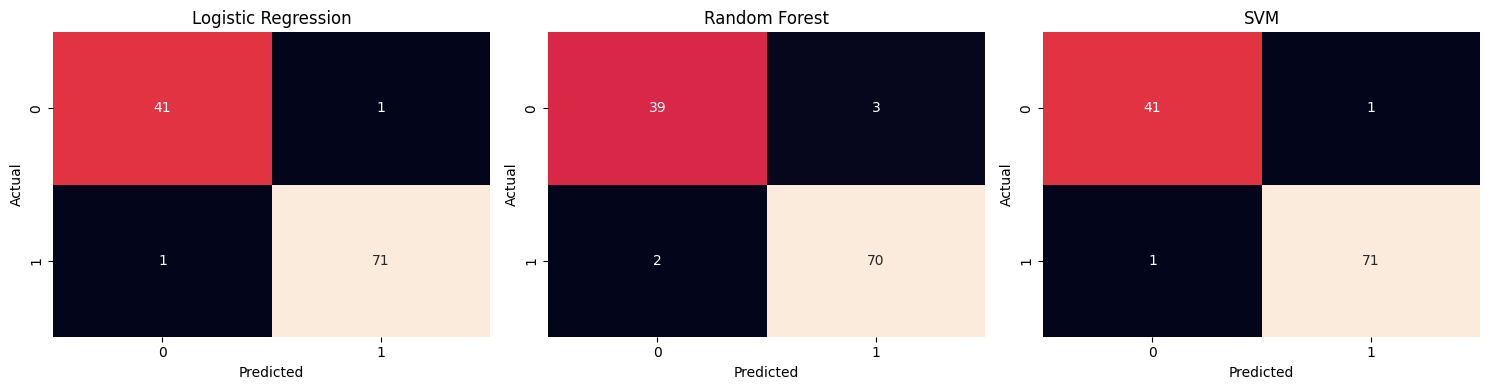

In [14]:



from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))



sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt='d',
    ax=axes[0],
    cbar=False
)
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')


sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    ax=axes[1],
    cbar=False
)
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# SVM
sns.heatmap(
    confusion_matrix(y_test, y_pred_svm),
    annot=True,
    fmt='d',
    ax=axes[2],
    cbar=False
)
axes[2].set_title('SVM')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

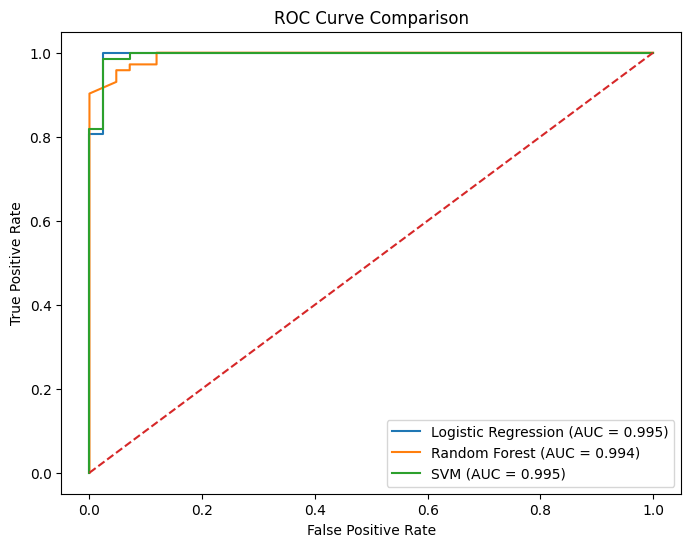

In [15]:



from sklearn.metrics import roc_curve, roc_auc_score



y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]



fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)



auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_svm = roc_auc_score(y_test, y_prob_svm)



plt.figure(figsize=(8, 6))

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

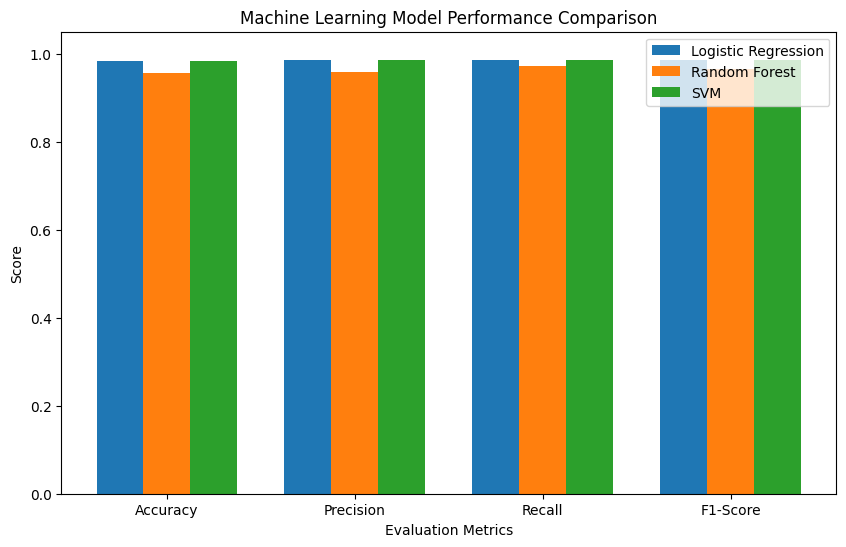

In [16]:



metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, results.iloc[0][metrics], width, label='Logistic Regression')
plt.bar(x, results.iloc[1][metrics], width, label='Random Forest')
plt.bar(x + width, results.iloc[2][metrics], width, label='SVM')

plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.title('Machine Learning Model Performance Comparison')

plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.legend()

plt.show()

In [17]:



from sklearn.metrics import classification_report

print("===== Logistic Regression =====")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=data.target_names
))

print("\n===== Random Forest =====")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=data.target_names
))

print("\n===== SVM =====")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=data.target_names
))

===== Logistic Regression =====
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


===== Random Forest =====
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


===== SVM =====
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       11

In [18]:



best_model = results.loc[results['F1-Score'].idxmax(), 'Model']
best_f1 = results['F1-Score'].max()

print("Best Performing Model:", best_model)
print("Best F1-Score:", round(best_f1, 4))

Best Performing Model: Logistic Regression
Best F1-Score: 0.9861


In [19]:



print("===== Conclusion =====\n")

print("Machine learning techniques can be effectively used for disease prediction.")
print("Among the three models, Logistic Regression and SVM performed the best.")
print("Both models achieved 98.25% accuracy on the test dataset.")
print("The results demonstrate that proper preprocessing and model selection")
print("can provide highly accurate predictions for the selected disease dataset.")

===== Conclusion =====

Machine learning techniques can be effectively used for disease prediction.
Among the three models, Logistic Regression and SVM performed the best.
Both models achieved 98.25% accuracy on the test dataset.
The results demonstrate that proper preprocessing and model selection
can provide highly accurate predictions for the selected disease dataset.
